# **Multi-Channel Marketing Analysis**

## **Introduction**

In this project, I will analyze historical marketing promotion data to explore the impact and relationship between a company sales and promotional budgets (TV, Radio, Social Media, and Influencers) using machine learning and statistical modeling techniques in Python. My goal is to help the company optimize its marketing strategies by identifying which promotional channel most effectively drive sales. Using Python, I will perform exploratory data analysis (EDA), data cleaning, and multiple linear regression statistical modeling to examine relationships between marketing investments and sales performance, validating regression assumptions and interpreting coefficients to quantify each channel's impact.

🔗 Explore the GitHub repo here: [GitHub Repository](https://github.com/Chinaice07/Multi-Channel-Marketing-Analysis)



## Overview
**To achieve the objectives of this project, I will:**

* Load the dataset, clean dataset and perform initial exploratory data analysis.
* Check for multicollinearity among independent variables using correlation matrices and VIF.
* Build a Multiple Linear Regression model using `statsmodels` to predict Sales.
* Evaluate model performance using *Adjusted R-squared* and individual predictor p-values.
* Create diagnostic plots to validate *Linearity*, *Normality*, and *Homoscedasticity* of residuals.
* Interpret coefficients in context.
* Synthesize findings into a clear, business-ready recommendation.


## **Dataset Structure**  
### **Marketing Sales Dataset**  
The dataset `'marketing_sales_data.csv'` contains historical marketing and sales data from various promotional campaigns. It includes information on different advertising channels and the corresponding sales revenue. The dataset helps analyze the relationship between marketing investments and sales performance.  

#### **Dataset Features**  
This dataset includes the following features:  
- **TV**: The level of investment in TV advertisements (Low, Medium, High).  
- **Radio**: The amount spent on radio promotions (in millions of dollars).  
- **Social Media**: The budget allocated to social media marketing (in millions of dollars).  
- **Influencer**: The type of influencer used in the campaign (Nano, Micro, Macro, Mega).  
- **Sales**: The total revenue generated from the marketing campaign (in millions of dollars).  

This dataset will be used to **analyze the impact of different marketing strategies on sales, build models to identify key drivers, and provide insights for optimizing marketing budgets.**

## **Import Necessary Libraries**

In [1]:
# for data handling, manipulation, and analysis
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for multiple linear regression modelling 
import statsmodels.api as sm
from statsmodels.formula.api import ols

# for checking multicollinearity using variance inflation factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import scipy.stats as stats

## **Data Preparation**

##### a. Data Ingestion and Cleaning

In [2]:
# load dataset using pandas
df = pd.read_csv('marketing_sales_data.csv')

In [3]:
# display the first few rows to confirm column names
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [4]:
# check for missing values in the dataset
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

> The dataset is clean and do not need to be cleaned further.

> To easily acces the Social Media column, we would have to rename to remove any whitespace within the words with a `'_'`

In [5]:
# rename the 'Social Media' column to 'Social_Media' for easier handling in regression formulas
df.rename(columns={'Social Media': 'Social_Media'}, inplace=True)

In [6]:
# display the first few rows again to confirm the column rename
display(df.head())

,TV,Radio,Social_Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


##### b. Feature/Data Encoding
> Since tools (such as statmodel) to be used later can only parse numerical data, we need to encode (or map) non-numerical data.
>
> The "TV" and "Influencer" are two non-numerical data which we need to encode with their numerical equivalent.
>
> We need to find the range values that is present (unique) to each column. This is to determine how the data is to be encoded.


In [7]:
# first, let's check the unique values in the 'TV' column
print(df['TV'].unique())

<StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str


In [8]:
# next, let's check the unique values in the 'Influencer' column
print(df['Influencer'].unique())

<StringArray>
['Micro', 'Mega', 'Nano', 'Macro']
Length: 4, dtype: str


We can dedude from the output that:
> TV is categorized as "Low," "Medium," or "High" 
>
> Influencer is categorized as "Mega," "Macro," "Micro," or "Nano"
>
> The two columns are ordinal data. i.e, they can be arranged in their ranking, natural, and logical order.

> For the specific context of our dataset:
>
>'TV' column will be encoded as:
    `Low (0)` → `Meduim (1)` → `High (2)` based on spend categorization.
>
> 'Influencer' column will be encoded as: 
    `Nano (0)` → `Micro (1)` → `Macro (2)` → `Mega (3)` based on follower's size.

> This is mathematically relevant as our model would understand that "High" is worth more than "Low" and "Mega" is worth more than "Macro" which is the actual case. The category order is defined based on external industry metrics, rather than relying on the dataset for the categorization.




In [9]:
# now we map the 'TV' and 'Influencer' column to numeric values
TV_encoding = {'Low': 1, 'Medium': 2, 'High': 3}
influencer_encoding = {'Nano': 0, 'Micro': 1, 'Macro': 2, 'Mega': 3}

# Apply it to your dataframe
df['TV_encoded'] = df['TV'].map(TV_encoding)
df['Influencer_encoded'] = df['Influencer'].map(influencer_encoding)

In [10]:
df.head(5)

,TV,Radio,Social_Media,Influencer,Sales,TV_encoded,Influencer_encoded
0,Low,3.518070,2.293790,Micro,55.261284,1,1
1,Low,7.756876,2.572287,Mega,67.574904,1,3
2,High,20.348988,1.227180,Micro,272.250108,3,1
3,Medium,20.108487,2.728374,Mega,195.102176,2,3
4,High,31.653200,7.776978,Nano,273.960377,3,0


>**Note:** 'TV_encoded' will mean the same thing as 'TV' and 'Influencer_encoded' they may be used interchangeably in future markdown and code comments

## **Exploratory Data Analysis & Multicollinearity Check**

#### 1. Visualizing relationships using a pairplot

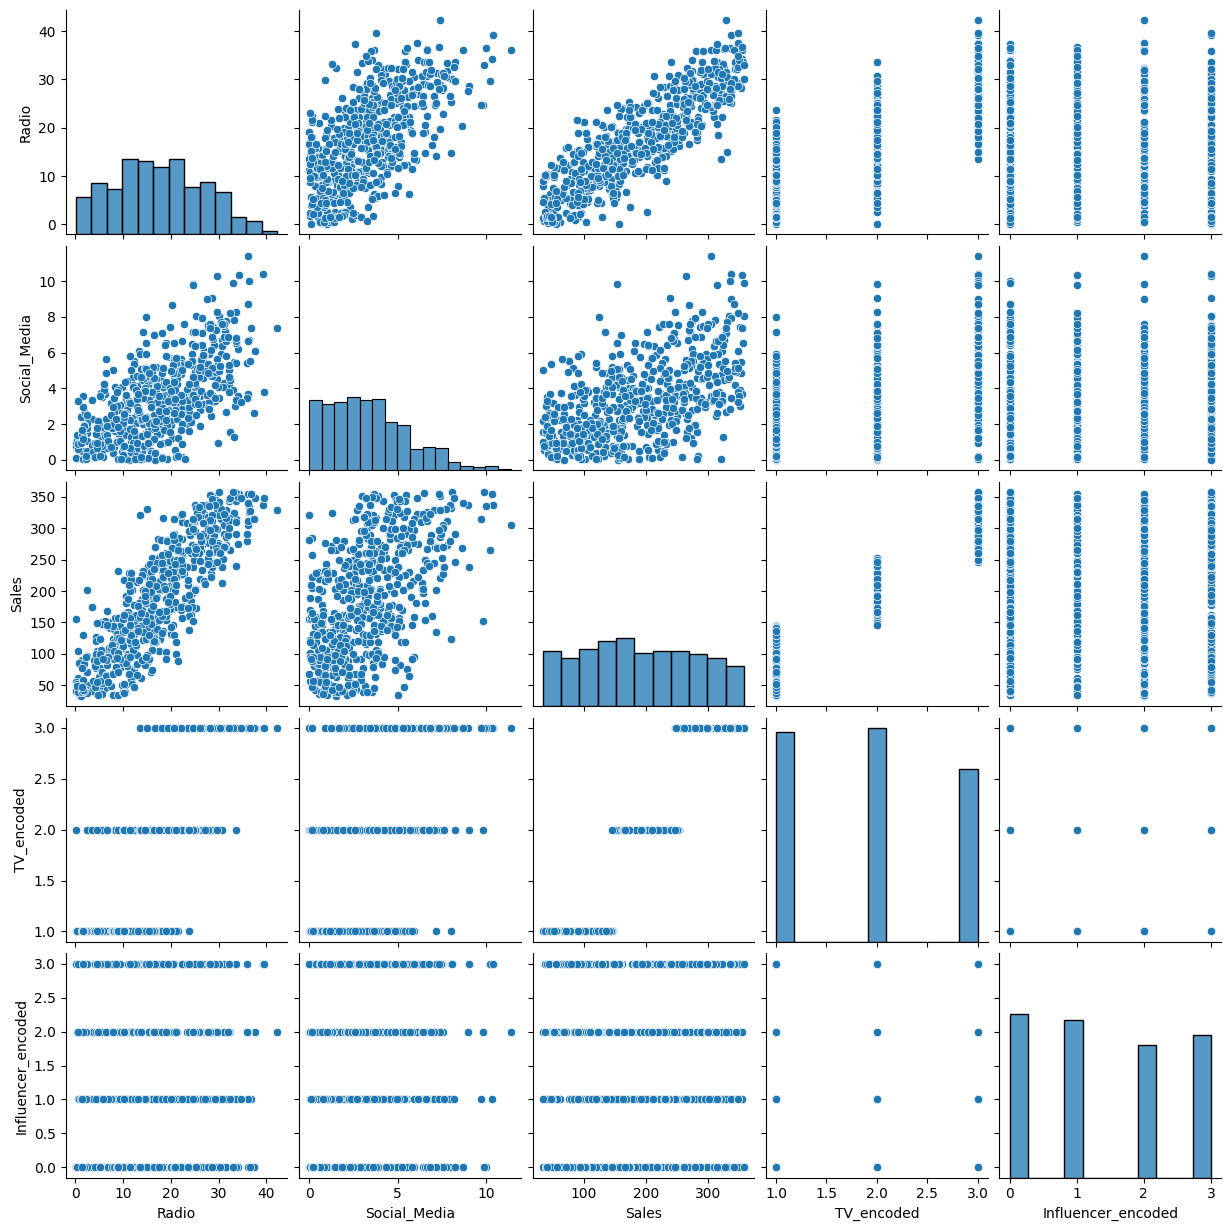

In [11]:
sns.pairplot(df)
plt.show()

**Analytical Reasoning — Pairplot Evaluation:**
>- **Radio** shows a **strong** linear relationship with `Sales`, making it a promising independent variable.  
>- **Social Media** also has a linear relationship, though the data points appear more scattered compared to `Radio`.
>- **TV_encoded** and **Influencer_encoded** shows no linear relationship with `Sales`, making it a less promising independent variable.

#### 2. Correlation Matrix

,Radio,Social_Media,Sales,TV_encoded,Influencer_encoded
Radio,1.000000,0.629941,0.858036,0.803377,0.000465
Social_Media,0.629941,1.000000,0.542048,0.511758,0.023150
Sales,0.858036,0.542048,1.000000,0.933169,0.000847
TV_encoded,0.803377,0.511758,0.933169,1.000000,-0.004017
Influencer_encoded,0.000465,0.023150,0.000847,-0.004017,1.000000


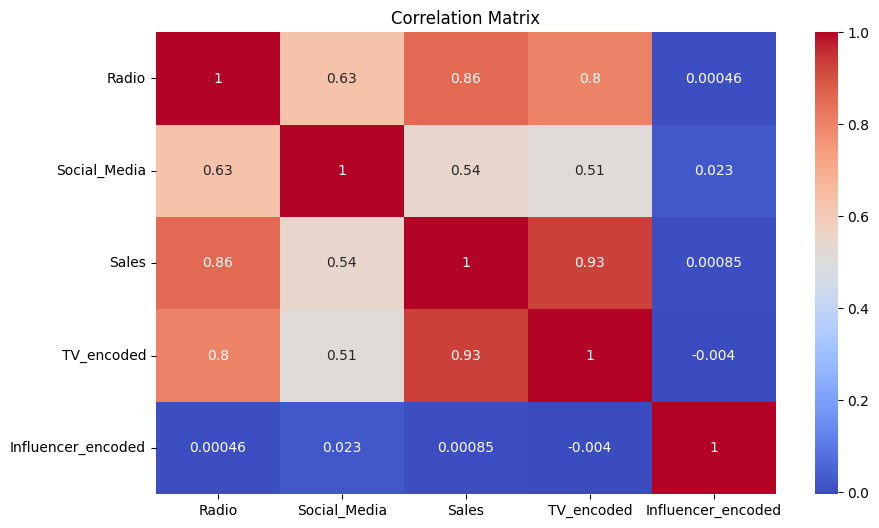

In [12]:
display(df.corr(numeric_only=True))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Analytical Reasoning — Correlation Matrix Evaluation:**
>- **TV_encoded** shows the highest correlation `(0.93)` with sales. This signals that it might be a good predictor of sales and might have to be used in the model.
>- **Radio** shows the ssecond highest correlation `(0.86)` with sales solidifying it's position as an independent variable and predictor of sales.
>-  **Social_Media** shows a neutral to moderate correlation `(0.54)` with sales. This keeps it as a possible independent variable to predict sales.
>- **Influencer_encoded** has a very little correlation `(0.00085)` with sales.
The pairplot and the correlation matrix shows that `Influencer_encoded` might not be a good predictor of sales.

#### 3. **Multicollinearity**

>Multicollinearity occurs when independent variables are highly correlated with *each other*, confusing the model. 

In [13]:
# 3. Calculating Variance Inflation Factor (VIF)
# We isolate only the predictor variables (X) and add a constant for the math to work
X_predictors = df[['TV_encoded', 'Radio', 'Social_Media', 'Influencer_encoded']]
X_vif = sm.add_constant(X_predictors)

# Create a dataframe to store the VIF results
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\nVariance Inflation Factor (VIF):")
display(vif_data)



Variance Inflation Factor (VIF):


,Feature,VIF
0,const,8.640308
1,TV_encoded,2.820790
2,Radio,3.451760
3,Social_Media,1.659591
4,Influencer_encoded,1.000927


**Analytical Reasoning — Multicollinearity Evaluation:**
>
> * Looking at the VIF table, `TV` (2.82), `Radio` (3.45), `Social_Media` (1.66) and `Influencer` (1) have VIF scores under 5, which is excellent. 
>
> * The `Influencer` VIF value of 1.0009 means this variable has almost zero mathematical correlation with any of the other marketing channels. It is completely independent. This means the choice of influencer tier is randomized or spread out evenly, regardless of how much budget was spent on other marketing channels.
> * Because every single one of the marketing channels has a VIF well under the strict threshold of 5, **there's no severe multicollinearity and hence no variable needs to be dropped**. The model will be able to handle all three of them perfectly.

>**Note**: The const VIF of 8.64 is ignored, that is just the math baseline.


## Feature Selection
I assumed **TV** and **Radio** as independent variables:
- **TV** was chosen because the it has the highest correlation with sales and showed a fairly low VIF value (2.82), suggesting it could be a strong predictor of `Sales`. 
- **Radio** was included because the **scatterplot matrix (`sns.pairplot`)** indicated a **strong linear relationship** between `Radio` and `Sales`. 

- **Social_Media** and **Influencer** were dropped due their low correlation and weak linear relationship with `Sales`. Despite their VIF values showing they could be independent predictors, other metrices and visualization plots show that they could be weak  predictor of `Sales`.

*I would build the initial model incorporating all the variables  to see how they perfrom and how the assumed selected features fair before finally dropping statistical insignificant variables.*

## **Building the Multiple Linear Regression Model**

> Since severe multicollinearity is completely absent, we can safely proceed to **Statistical Modeling** with absolute confidence that our regression coefficients will be mathematically stable, precise, and reliable for business decision-making.

In [14]:
# Define the formula: Sales depends on TV, Radio, Social Media, and Influencer_encoded.
ols_formula = 'Sales ~ TV_encoded + Radio + Social_Media + Influencer_encoded'

# Fit the Multiple Linear Regression model
initial_model = ols(formula=ols_formula, data=df).fit()

# Print the comprehensive summary table
print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1334.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          9.28e-287
Time:                        22:40:13   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -12.6930      3

> The `p-values [P>|t|]` of `Social_Media (0.809)` and `Influencer_encoded (0.785)` shows that the variables are statistical insignificant to our model.

> Ths aligns with our featue selection assumptions. This proof has solidify our position to drop these variables and build our model using the `Radio` and `TV_encoded` columns.

### **Final Parsimonious Model**

> In statistics, the rule of Parsimony (Occam's Razor) is followed. This suggests that the simplest model that explains the data is always the best model. Two metrics are used to measure this: AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion). A lower scores mean a better, more efficient model.

> This follows that our initial feature selction assumption: `Radio` and `TV` were correct and were the most relevat to our predictor model and are now our selected features. 

In [15]:
# Redefine the formula to reflect only statistical relevant features.
ols_formula = 'Sales ~ TV_encoded + Radio'

# Fit the final model
model = ols(formula=ols_formula, data=df).fit()

model_results = model.summary()
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          3.70e-290
Time:                        22:40:13   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.3902      3.066     -4.041      0.000     -18.412      -6.368
TV_encoded    77.3156      2.454     31.512      0.000      72.497      82.135
Radio          2.9558      0.211     14.002      0.000       2.541       3.370
==============================================================================
Omnibus:                       60.364   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.980
Skew:                           0.050   Prob(JB):                     0.000125
Kurtosis:                       2.137   Cond. No.                         60.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

>Looking at model results:
>
>- The **Adjusted R-squared** value increased from 0.903 to 0.904, aligning with the **R-squared** value.
>
>- The AIC and BIC values compared with the old model:
>
>    - **AIC** dropped from *5438* to *5435*
>
>    - **BIC** dropped from *5460* to *5446*

>  **Intepretation**:
>- Since the **Adjusted R-squared is the same as R-squared**, it confirms that the model does not include unnecessary predictors, reinforcing its robustness. 
>- Because both the AIC and BIC metrics decreased in the final model, the mathematical framework explicitly signals that the model has **improved**. The lower scores prove that removing statistically insignificant features improves the model's efficiency, avoiding the mathematical penalty for unnecessary complexity.

>Therefore, our model **\($\text{Sales} = \beta_{0} + \beta_{TV}*X_{TV}+ \beta_{Radio}*X_{Radio}$)** is the simplest model that best predict sales.



## **Checking Model Assumptions**

I will check three multiple linear regression assumptions are upheld for my model. I would now create diagnostic plots to validate *Linearity*, *Normality*, and *Homoscedasticity* of residuals.

### **Assumption 1: Linearity**
I will create scatterplots comparing the continuous independent variable(s) I selected previously with `Sales` to check the linearity assumption. I will use the pairplot I created earlier to verify the linearity assumption or create new scatterplots comparing the variables of interest.

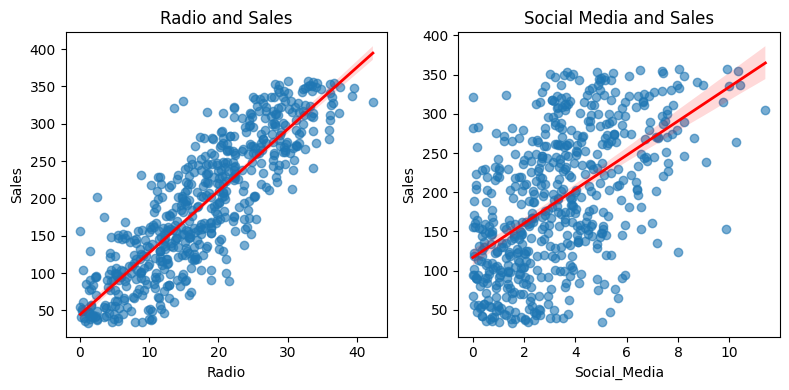

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.regplot(x='Radio', y='Sales', data=df, ax=axes[0], line_kws={'color':'red', 'linewidth': 2}, scatter_kws={'alpha': 0.6})
axes[0].set_title("Radio and Sales")

sns.regplot(x='Social_Media', y='Sales', data=df, ax=axes[1], line_kws={'color':'red', 'linewidth': 2}, scatter_kws={'alpha': 0.6})
axes[1].set_title("Social Media and Sales")

plt.tight_layout()
plt.show()

#### **Analytical Findings:**
The linearity assumption is met.  
>- **Radio** satisfies the assumption, as the scatterplot shows a **fair linear relationship** between `Radio` and `Sales`.  
>- **Social Media** was not included in the final multiple linear regression model, and it also appears to have almost no **linear relationship** with `Sales`.  

These observations confirm that the selected variables align with the linearity assumption necessary for multiple linear regression.  

### **Assumption 2: Normality**
I will create the following plots to check the **normality assumption**:  

- **Plot 1**: Histogram of the residuals  
- **Plot 2**: Q-Q plot of the residuals

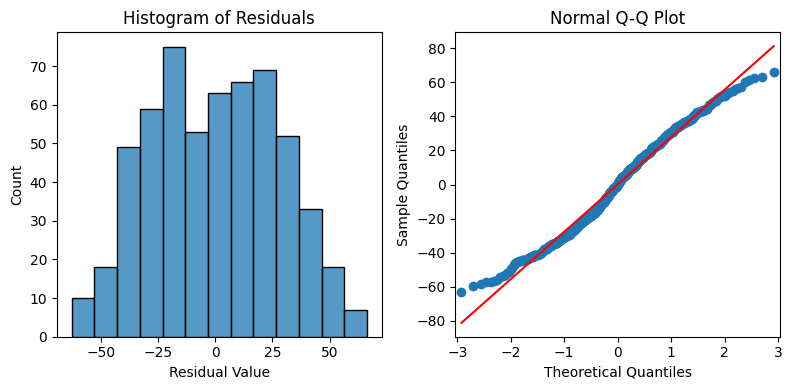

In [17]:
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.histplot(residuals, ax=axes[0])
axes[0].set_title("Histogram of Residuals")
axes[0].set_xlabel("Residual Value")

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()


#### **Analytical Findings:**
The normality assumption is met.  

- The **histogram of residuals** appears approximately **normally distributed**, supporting this assumption.  
- The **Q-Q plot** shows that the residuals align mostly with a **straight line**, further confirming normality.  

These visualizations indicate that the residuals follow a normal distribution, meeting the assumption for multiple linear regression.  



### **Assumption 3: Homoscedasticity-Constant variance**
I will check that the **constant variance assumption** is not violated by creating a scatterplot with the fitted values and residuals. I will add a reference line at \( y = 0 \) to visualize the variance of residuals above and below the line.

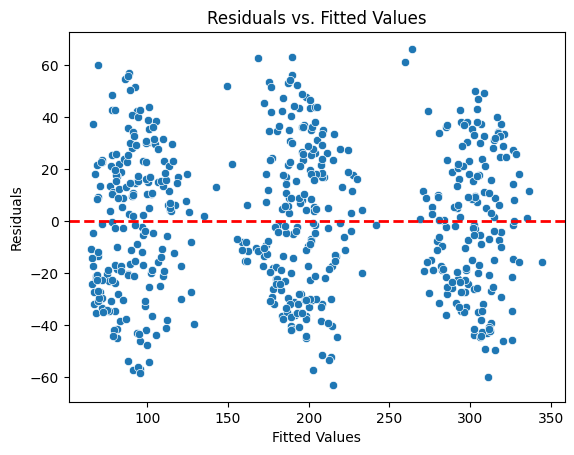

In [18]:
# Map predicted values against model errors to test for constant variance
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

#### **Analytical Findings:**
The constant variance (homoscedasticity) assumption appears to be met.  

- The fitted values are grouped into three clusters due to the categorical nature of **TV**, which is the dominant predictor of `Sales`.  
- However, **within each TV category**, the residuals exhibit a **similar spread (variance)**, suggesting that homoscedasticity holds.  
- Even if the overall residual plot seems somewhat heteroscedastic, what matters is that the variance remains **consistent within each category**, supporting the assumption.  

These observations indicate that the assumption of **constant variance** is likely satisfied.  
Key Improvements:

## **Results and Evaluation**

### **Displaying OLS Regression Results**
Now that the model assumptions have been checked, I will analyze the **regression results**.

In [19]:
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          3.70e-290
Time:                        22:40:13   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.3902      3.066     -4.041      0.000     -18.412      -6.368
TV_encoded    77.3156      2.454     31.512      0.000      72.497      82.135
Radio          2.9558      0.211     14.002      0.000       2.541       3.370
==============================================================================
Omnibus:                       60.364   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.980
Skew:                           0.050   Prob(JB):                     0.000125
Kurtosis:                       2.137   Cond. No.                         60.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Interpreting the R-Squared Value**
The model has an **R-squared value of 0.904**, meaning it explains **90.4% of the variance** in `Sales`.  

- This indicates that the **independent variables (`TV` and `Radio`) effectively predict `Sales`**.  
- A high **R-squared** suggests that a **significant proportion of the variability** in `Sales` is accounted for by the model.  
- Additionally, since the **Adjusted R-squared is the same as R-squared**, it confirms that the model does not include unnecessary predictors, reinforcing its robustness.  

Overall, this high R-squared value suggests that the model is an **excellent predictor** of `Sales`.  


### Relationship between `Sales` and the independent variables as a linear equation

When `TV` and `Radio` are used to predict `Sales`, the model coefficients are:

* $\beta_{0} =  -12.3902$
* $\beta_{TV} = 77.3156$
* $\beta_{Radio} =  2.9558$

Now establishing the relationship:

$\text{Sales} = \beta_{0} + \beta_{1}*X_{1}+ \beta_{2}*X_{2}$

$\text{Sales} = \beta_{0} + \beta_{TV}*X_{TV}+ \beta_{Radio}*X_{Radio}$

$\text{Sales} =  - 12.3902 + 77.3156*X_{TV} + 2.9558 *X_{Radio}$

The estimated coefficients provide insights into the relationship between `TV` and `Radio` advertising budgets and `Sales`.  

### **Interpretation of Model Coefficients:**  
- **Intercept (β₀ = -12.3902):**  
  - Represents the estimated `Sales` when the `TV` budget and the `Radio` budget is **0**.  
  - While mathematically valid, this scenario may not be realistic in practice.  

- **TV Advertising (Categorical Variable)**:  
  - **β₁ (`TV` = 77.3156):**  
    - Holding the Radio budget constant, upgrading the TV promotional budget by one tier (e.g., from Low to Medium, or Medium to High) is associated with an estimated increase in Sales of 77.32 million dollars.

- **Radio Advertising (Continuous Variable)**:  
  - **β₂ ​(`Radio` = 2.9558):**  
    - For every **1 million increase** in the `Radio` budget, `Sales` are expected to **increase by 2.96 million**, assuming the `TV` budget category remains unchanged.  

### **Statistical Significance**
- All coefficients are **statistically significant**.
- **p-values = 0.000** for all predictors, meaning they are significant at **p < 0.05**.  

### **Model Limitations**

While the final parsimonious model performs exceptionally well ($R^2 = 0.904$), it is important to acknowledge its limitations before drawing definitive business conclusions:

* **Omitted Variable Bias:** The current model assumes that variance in sales is driven entirely by marketing spend. It does not account for external variables that likely make up the remaining 9.6% of unexplained variance. Missing factors include:
    * **Seasonality:** Holiday spikes or slower purchasing periods.
    * **Economic Factors:** Macroeconomic conditions affecting consumer purchasing power.
    * **Market Dynamics:** Competitor pricing, promotions, and overall market share.
* **Categorical Constraints of TV Spend:** The `TV` variable is grouped into broad ordinal categories (Low, Medium, High). While mathematically functional, lacking the continuous, exact dollar amounts for TV spend limits our ability to calculate a highly granular Return on Investment (ROI) for that specific channel.

## **Final Thoughts**  
The results highlight that **TV advertising plays a crucial role** in driving `Sales`, with higher budgets leading to significantly **better performance**. `Radio` advertising also contributes positively, but at a **smaller scale** per unit increase in spending. These findings are statistically robust and provide actionable insights for **budget allocation** in marketing strategies.  

## **Strategic Recommendations** 
   - **TV advertising should be prioritized**, as reductions in TV spending lead to significant sales declines.  
   - **Radio should be leveraged as a secondary driver** to further enhance sales growth.  
   - **Future analysis should explore additional factors**, such as seasonality, pricing strategies, and digital marketing impact.  

By structuring these findings clearly, I can provide stakeholders with the insights they need to **optimize marketing budgets and drive sales growth** effectively.

## ✨ **Credits**
- [saswatsethda on Kaggle: Influencer Marketing Sales Modelling and Analysis](https://www.kaggle.com/code/saswatsethda/influencer-marketing-sales-modeling-and-analysis#Multiple-Linear-Regression:-Model-Building-and-Evaluation)

- [Chinaice07 on Github: Marketing ROI Analysis](https://github.com/Chinaice07/Marketing-ROI-Analysis)